# ProductType Classification: 3-Feature Probability Model

This notebook applies the parent ProductType pipeline to `ProductType`, `ProductGroup`, `ProductFamily`, `ProductLine`, and `ProductKey` using the same three inputs: `GPCBrickCode`, `UNSPSCNumber`, and `ProductDescription`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import joblib
import seaborn as sns


RANDOM_STATE = 42

# --- palette: one dict, referenced by role/slot instead of one variable per color ---
PALETTE = {
    "surface":     "#fcfcfb",
    "ink_primary": "#0b0b0b",
    "ink_secondary": "#52514e",
    "ink_muted":   "#898781",
    "gridline":    "#e1e0d9",
    "baseline":    "#c3c2b7",
    "categorical": ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
                     "#e87ba4", "#008300", "#4a3aa7", "#e34948"],
    "sequential_blue": ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5",
                         "#256abf", "#184f95", "#0d366b"],
}
blue_cmap = LinearSegmentedColormap.from_list("blue_seq", PALETTE["sequential_blue"])

plt.rcParams.update({
    "figure.facecolor": PALETTE["surface"],
    "axes.facecolor": PALETTE["surface"],
    "axes.edgecolor": PALETTE["baseline"],
    "axes.labelcolor": PALETTE["ink_secondary"],
    "text.color": PALETTE["ink_primary"],
    "xtick.color": PALETTE["ink_muted"],
    "ytick.color": PALETTE["ink_muted"],
    "grid.color": PALETTE["gridline"],
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## Load data

In [2]:
DATA_PATH = "datasets/product_classified_Full.xlsx"
CAT_FEATURES = ["GPCBrickCode", "UNSPSCNumber"]
TEXT_FEATURE = "ProductDescription"
TARGETS = ["ProductType", "ProductGroup", "ProductFamily", "ProductLine", "ProductKey"]

df = pd.read_excel(DATA_PATH, sheet_name="in")
df = df[CAT_FEATURES + [TEXT_FEATURE] + TARGETS].copy()
print(df.shape)
df.head()

(10237, 8)


,GPCBrickCode,UNSPSCNumber,ProductDescription,ProductType,ProductGroup,ProductFamily,ProductLine,ProductKey
0,NaN,NaN,NaN,Main Products,Adult Patient Simulators,Ultrasound,SONOSIM,AAPO
1,NaN,NaN,NaN,To be decided,Adult Patient Simulators,Advanced Patient Simulators,SimMan 3G,ITPO
2,NaN,NaN,NaN,To be decided,Adult Patient Simulators,Advanced Patient Simulators,SimMan 3G,ITPO
3,10005844 - Medical Devices,42301502.0,NeoNatalie is an inflatable simulator designed...,Main Products,Adult Patient Simulators,Basic Patient Simulators,NeoNatalie kit,AAPC
4,10005844 - Medical Devices,42301502.0,NeoNatalie is an inflatable simulator designed...,Main Products,Adult Patient Simulators,Basic Patient Simulators,NeoNatalie kit,AAPC


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10237 entries, 0 to 10236
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   GPCBrickCode        8938 non-null   str    
 1   UNSPSCNumber        8759 non-null   float64
 2   ProductDescription  3912 non-null   str    
 3   ProductType         10237 non-null  str    
 4   ProductGroup        10237 non-null  str    
 5   ProductFamily       10237 non-null  str    
 6   ProductLine         10237 non-null  str    
 7   ProductKey          10237 non-null  str    
dtypes: float64(1), str(7)
memory usage: 2.4 MB


In [4]:
df.isna().sum()

GPCBrickCode          1299
UNSPSCNumber          1478
ProductDescription    6325
ProductType              0
ProductGroup             0
ProductFamily            0
ProductLine              0
ProductKey               0
dtype: int64

In [5]:
resdf=(
    df.groupby(
        ["GPCBrickCode", "UNSPSCNumber", "ProductDescription"],
        dropna=False
    )
    .size()
    .reset_index(name="count")
)

In [6]:
resdf[resdf['count']>10].sort_values(by='count',ascending=False)

,GPCBrickCode,UNSPSCNumber,ProductDescription,count
591,10007598 - Maintenance/Repair Services,72151800.0,NaN,1453
1258,99999999 - Temporary Classification,42301502.0,NaN,1212
1728,NaN,NaN,NaN,650
1466,99999999 - Temporary Classification,NaN,SimMan 3G is a durable patient simulator creat...,250
966,99999999 - Temporary Classification,42301501.0,NaN,223
...,...,...,...,...
715,99999999 - Temporary Classification,42172105.0,The Laerdal ALS Baby is a portable skill train...,12
1185,99999999 - Temporary Classification,42301502.0,SimNewB is a newborn tetherless simulator co-c...,12
1084,99999999 - Temporary Classification,42301502.0,MamaNatalie birthing simulator that comes with...,12
283,10001138 - Computer Software (Non Games),55111513.0,NaN,11


In [7]:
mask = df[["GPCBrickCode", "UNSPSCNumber", "ProductDescription"]].isna().all(axis=1)

df[mask]

,GPCBrickCode,UNSPSCNumber,ProductDescription,ProductType,ProductGroup,ProductFamily,ProductLine,ProductKey
0,NaN,NaN,NaN,Main Products,Adult Patient Simulators,Ultrasound,SONOSIM,AAPO
1,NaN,NaN,NaN,To be decided,Adult Patient Simulators,Advanced Patient Simulators,SimMan 3G,ITPO
2,NaN,NaN,NaN,To be decided,Adult Patient Simulators,Advanced Patient Simulators,SimMan 3G,ITPO
12,NaN,NaN,NaN,Service Parts,Adult Patient Simulators,Basic Patient Simulators,Resusci Anne Simulator,AASS
22,NaN,NaN,NaN,Main Products,Adult Patient Simulators,Ultrasound,SONOSIM,AADO
...,...,...,...,...,...,...,...,...
9827,NaN,NaN,NaN,Service Agreement,Technical Services(SVG),Preventative Maintenance,Emily/Emma High Emotion Simulation,CHSL
9828,NaN,NaN,NaN,Service Return to Laerdal,Technical Services(SVG),Service Center Tech Svcs,Emily/Emma High Emotion Simulation,CHSL
9829,NaN,NaN,NaN,Service Return to Laerdal,Technical Services(SVG),Service Center Tech Svcs,Paul High Emotion Simulation,CHSL
9846,NaN,NaN,NaN,Software Products,Virtual Simulation & e-Learning,Competence Management System,Training Products,ITPO


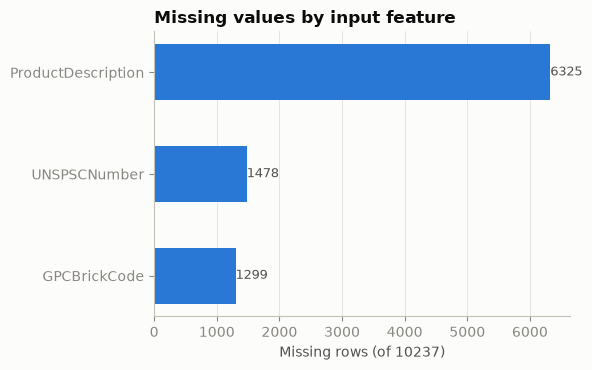

In [8]:
TEXT_FEATURES = ["ProductDescription"]

missing = df[CAT_FEATURES + TEXT_FEATURES].isna().sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 3.8))
bars = ax.barh(missing.index[::-1], missing.values[::-1], color=PALETTE["categorical"][0], height=0.55)
ax.set_xlabel("Missing rows (of %d)" % len(df))
ax.set_title("Missing values by input feature", loc="left", fontweight="bold", color=PALETTE["ink_primary"])
ax.grid(axis="x", linewidth=0.6)
ax.set_axisbelow(True)
for b, v in zip(bars, missing.values[::-1]):
    ax.text(v + 1, b.get_y() + b.get_height()/2, str(v), va="center", color=PALETTE["ink_secondary"], fontsize=9)
plt.tight_layout()
plt.show()

In [9]:
df.dropna(subset=["GPCBrickCode", "UNSPSCNumber","ProductDescription"], how="all",inplace=True)

In [10]:
df.isna().sum()

GPCBrickCode           649
UNSPSCNumber           828
ProductDescription    5675
ProductType              0
ProductGroup             0
ProductFamily            0
ProductLine              0
ProductKey               0
dtype: int64

In [11]:
df.head()

,GPCBrickCode,UNSPSCNumber,ProductDescription,ProductType,ProductGroup,ProductFamily,ProductLine,ProductKey
3,10005844 - Medical Devices,42301502.0,NeoNatalie is an inflatable simulator designed...,Main Products,Adult Patient Simulators,Basic Patient Simulators,NeoNatalie kit,AAPC
4,10005844 - Medical Devices,42301502.0,NeoNatalie is an inflatable simulator designed...,Main Products,Adult Patient Simulators,Basic Patient Simulators,NeoNatalie kit,AAPC
5,99999999 - Temporary Classification,42301502.0,Bariatric complete suit in dark skin tone,Main Products,Adult Patient Simulators,Basic Patient Simulators,PNSuit,AAPO
6,99999999 - Temporary Classification,42301502.0,Bariatric complete suit in light skin tone,Main Products,Adult Patient Simulators,Basic Patient Simulators,PNSuit,AAPO
7,99999999 - Temporary Classification,42301502.0,Bariatric complete suit in medium skin tone,Main Products,Adult Patient Simulators,Basic Patient Simulators,PNSuit,AAPO


In [12]:
product_dfs = {
    TARGET: df[TARGET].value_counts().reset_index(name="count").sort_values(by="count")
    for TARGET in TARGETS
}

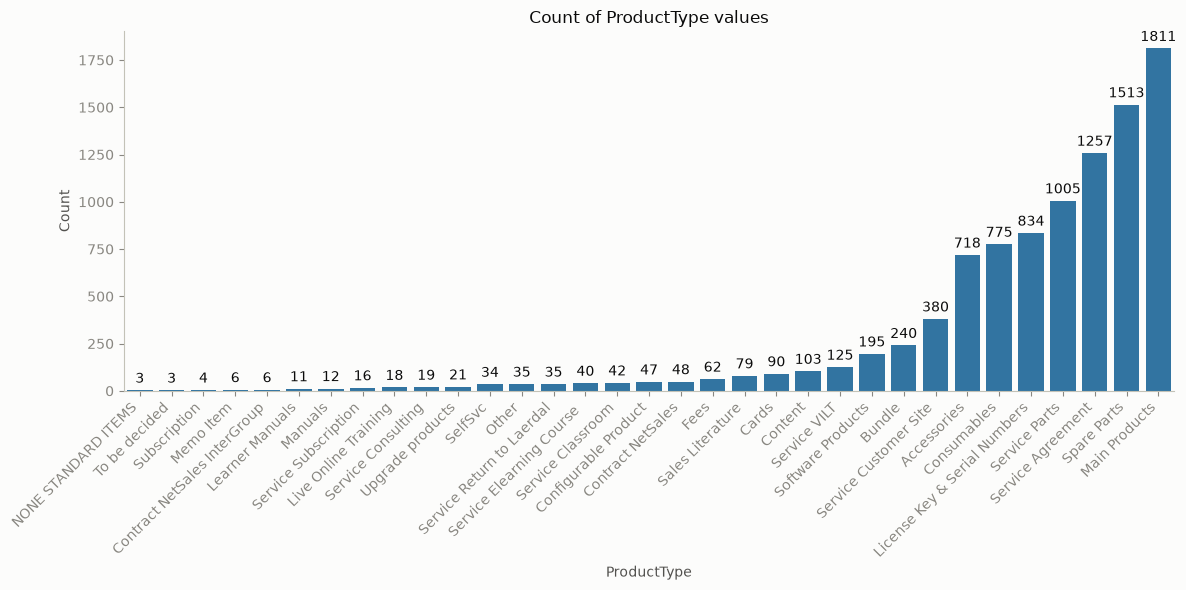

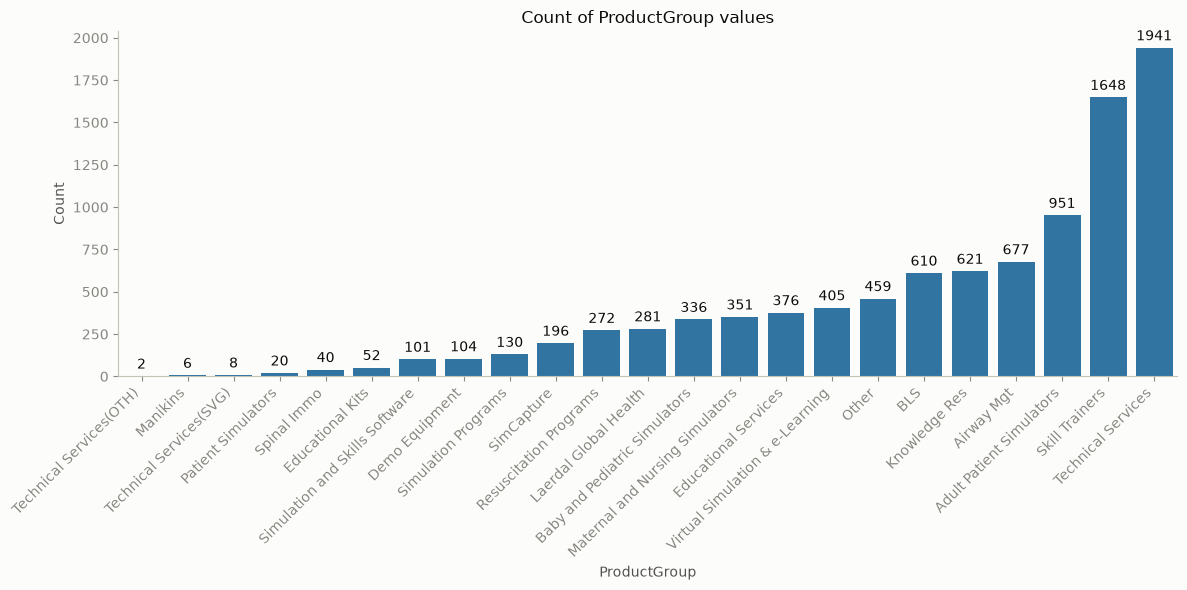


ProductFamily: top 20 of 97 values


,ProductFamily,count
0,Advanced Patient Simulators,1145
1,Value Plus,691
2,Preventative Maintenance,687
3,Intermediate Patient Simulators,538
4,American Heart Associaton,524
5,Ultrasound,466
6,3rd party product,297
7,Patient Care Manikins,289
8,Other,278
9,VSim,269



ProductLine: top 20 of 257 values


,ProductLine,count
0,SimMan 3G,579
1,Nursing Anne Simulator,467
2,Magic Ultrasound,373
3,vSim,320
4,Limbs and Things Products,276
5,SimBaby MK II,271
6,General Services,240
7,Erler Zimmer,226
8,Pocket Mask,212
9,SimMom,207



ProductKey: top 20 of 138 values


,ProductKey,count
0,ITPO,1724
1,CHSL,892
2,ADPP,610
3,JLPC,523
4,ADPT,505
5,DIDK,346
6,AAPS,345
7,ADPO,322
8,ISDP,314
9,GOPC,313


In [13]:
for TARGET in TARGETS[:2]:
    product_df = product_dfs[TARGET]

    plt.figure(figsize=(max(12, len(product_df) * 0.18), 6))

    ax = sns.barplot(
        data=product_df,
        x=TARGET,
        y="count"
    )

    # Add count labels on top of the bars
    for container in ax.containers:
        ax.bar_label(container, fmt="%d", padding=3)

    plt.title(f"Count of {TARGET} values")
    plt.xlabel(TARGET)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

for TARGET in TARGETS[2:]:
    counts = product_dfs[TARGET].sort_values("count", ascending=False)
    print(f"\n{TARGET}: top 20 of {len(counts)} values")
    display(counts.head(10))


ProductType
Unique (GPCBrickCode, UNSPSCNumber) combinations: 311
Weighted purity (codes alone -> ProductType): 58.9%
Rows in an ambiguous combination (>1 ProductType): 93.5%


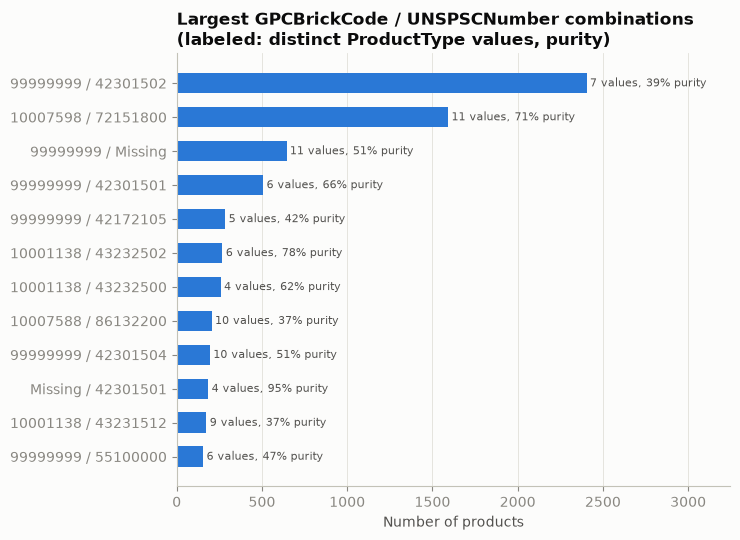


ProductGroup
Unique (GPCBrickCode, UNSPSCNumber) combinations: 311
Weighted purity (codes alone -> ProductGroup): 65.4%
Rows in an ambiguous combination (>1 ProductGroup): 90.8%


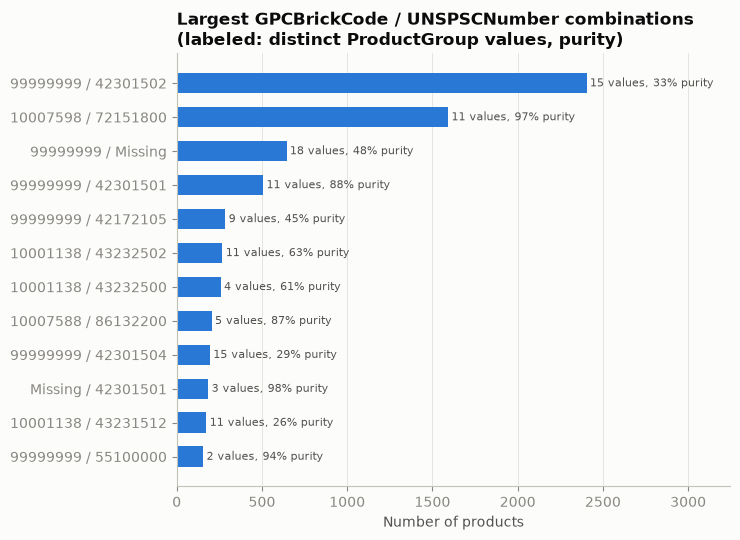


ProductFamily
Unique (GPCBrickCode, UNSPSCNumber) combinations: 311
Weighted purity (codes alone -> ProductFamily): 48.3%
Rows in an ambiguous combination (>1 ProductFamily): 91.5%


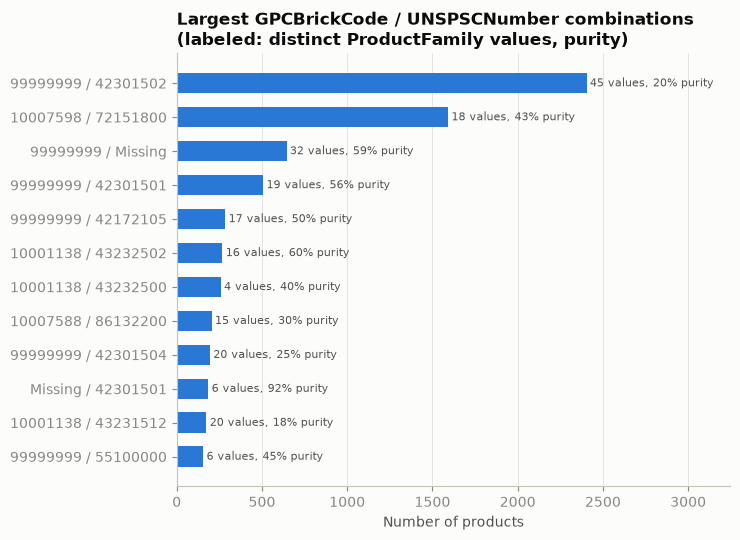


ProductLine
Unique (GPCBrickCode, UNSPSCNumber) combinations: 311
Weighted purity (codes alone -> ProductLine): 33.9%
Rows in an ambiguous combination (>1 ProductLine): 95.9%


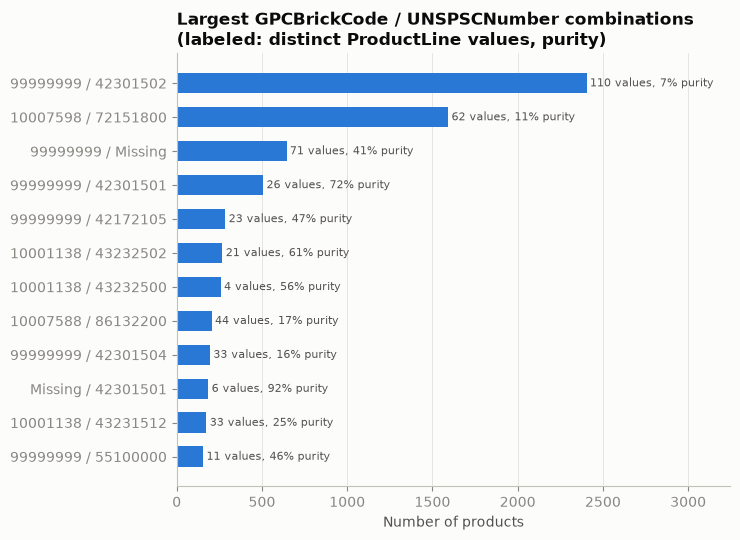


ProductKey
Unique (GPCBrickCode, UNSPSCNumber) combinations: 311
Weighted purity (codes alone -> ProductKey): 46.3%
Rows in an ambiguous combination (>1 ProductKey): 95.1%


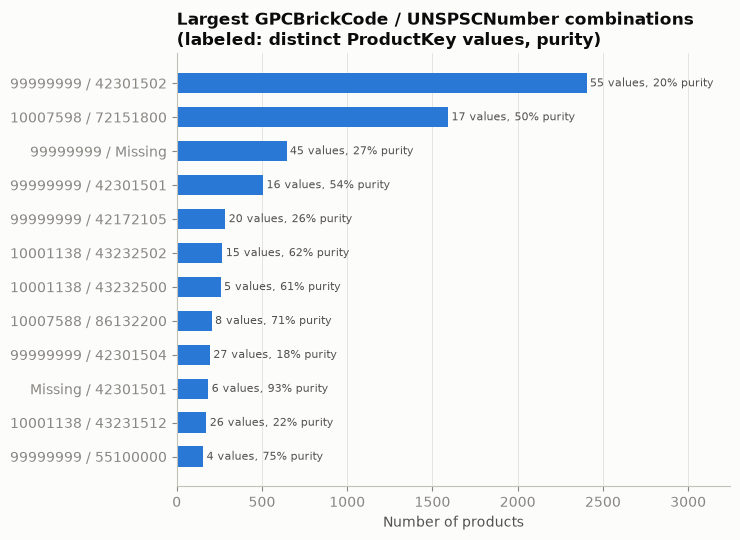

In [14]:
def short_label(gpc, unspsc):
    gpc_short = str(gpc).split(" - ")[0] if pd.notna(gpc) else "Missing"
    unspsc_short = str(int(unspsc)) if pd.notna(unspsc) else "Missing"
    return f"{gpc_short} / {unspsc_short}"


for TARGET in TARGETS:
    g = df.groupby(["GPCBrickCode", "UNSPSCNumber"], dropna=False)[TARGET]
    combo_stats = pd.DataFrame({
        "size": g.size(),
        "n_types": g.nunique(),
        "purity": g.agg(lambda s: s.value_counts().iloc[0] / len(s)),
    })

    weighted_purity = (combo_stats["purity"] * combo_stats["size"]).sum() / combo_stats["size"].sum()
    ambiguous = combo_stats[combo_stats["n_types"] > 1]
    ambiguous_row_share = ambiguous["size"].sum() / combo_stats["size"].sum()

    print(f"\n{TARGET}")
    print(f"Unique (GPCBrickCode, UNSPSCNumber) combinations: {len(combo_stats)}")
    print(f"Weighted purity (codes alone -> {TARGET}): {weighted_purity:.1%}")
    print(f"Rows in an ambiguous combination (>1 {TARGET}): {ambiguous_row_share:.1%}")

    top = combo_stats.sort_values("size", ascending=False).head(12).iloc[::-1]
    labels = [short_label(gpc, unspsc) for gpc, unspsc in top.index]

    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    bars = ax.barh(labels, top["size"], color=PALETTE["categorical"][0], height=0.6)
    ax.set_xlabel("Number of products")
    ax.set_title(f"Largest GPCBrickCode / UNSPSCNumber combinations\n(labeled: distinct {TARGET} values, purity)",
                 loc="left", fontweight="bold", color=PALETTE["ink_primary"])
    ax.grid(axis="x", linewidth=0.6)
    ax.set_axisbelow(True)
    for b, (n_types, purity) in zip(bars, zip(top["n_types"], top["purity"])):
        ax.text(b.get_width() + 20, b.get_y() + b.get_height() / 2,
                f"{n_types} values, {purity:.0%} purity",
                va="center", color=PALETTE["ink_secondary"], fontsize=8)
    ax.set_xlim(0, top["size"].max() * 1.35)
    plt.tight_layout()
    plt.show()

## Fold rare ProductType classes into `Other`

Same rule as the other notebooks: classes with fewer than 10 samples are folded into `Other` rather than dropped.

In [15]:
MIN_CLASS_COUNT = 10
for TARGET in TARGETS:
    type_counts = df[TARGET].value_counts()
    rare_types = type_counts[type_counts < MIN_CLASS_COUNT].index.tolist()
    print(f"Folding {len(rare_types)} {TARGET} classes with < {MIN_CLASS_COUNT} samples into 'Other':")
    print(rare_types)

    df[TARGET] = df[TARGET].where(~df[TARGET].isin(rare_types), "Other")
    print(f"\n{TARGET} classes: {type_counts.shape[0]} -> {df[TARGET].nunique()}")

Folding 5 ProductType classes with < 10 samples into 'Other':
['Memo Item', 'Contract NetSales InterGroup', 'Subscription', 'NONE STANDARD ITEMS', 'To be decided']

ProductType classes: 33 -> 28
Folding 3 ProductGroup classes with < 10 samples into 'Other':
['Technical Services(SVG)', 'Manikins', 'Technical Services(OTH)']

ProductGroup classes: 23 -> 20
Folding 34 ProductFamily classes with < 10 samples into 'Other':
['Manikin Airways', 'Simulation Courses', 'eLearning Partner', 'Preventive Maintenance Skin', 'Manikin Faces', 'Lippincott', 'Scenario', 'Curriculum', 'Head Immobilizers', 'Advanced Course', 'To be decided', 'Spineboards', 'LEARN Elearning modules', 'Product Courses', 'Charts', 'eLearning Laerdal', 'Books', 'Trauma & Rescue Skills Trainers', 'Monitors', 'Straps', 'Cleaning Solutions', 'AED trainers', 'Teaching Course', 'Subscription', 'Newborn', 'Consumer product', 'SimStore', 'Cardiac Skills Trainers', 'Little Anne ', 'Manikin FaceShield', 'Introduction Course', 'Mixed R

## Train / test split - on raw data, before any fitting

Split first, fit nothing on the full dataset. `OneHotEncoder` and any embedding statistics should only ever see the training rows; the test rows must stay unseen until evaluation, otherwise the "test" accuracy is partly measuring information that leaked in from the encoder having seen those exact category values already.

In [16]:
df["GPCBrickCode"] = df["GPCBrickCode"].fillna("Missing")
df["UNSPSCNumber"] = df["UNSPSCNumber"].fillna(-1).astype(int).astype(str)

model_data = {}
for TARGET in TARGETS:
    df_train, df_test = train_test_split(
        df, test_size=0.2, random_state=RANDOM_STATE, stratify=df[TARGET]
    )
    model_data[TARGET] = {
        "df_train": df_train,
        "df_test": df_test,
    }
    print(f"\n{TARGET}")
    print(f"Train: {len(df_train)}  Test: {len(df_test)}")
    print(f"Classes in train: {df_train[TARGET].nunique()}  Classes in test: {df_test[TARGET].nunique()} (of {df[TARGET].nunique()} total)")


ProductType
Train: 7669  Test: 1918
Classes in train: 28  Classes in test: 28 (of 28 total)

ProductGroup
Train: 7669  Test: 1918
Classes in train: 20  Classes in test: 20 (of 20 total)

ProductFamily
Train: 7669  Test: 1918
Classes in train: 63  Classes in test: 63 (of 63 total)

ProductLine
Train: 7669  Test: 1918
Classes in train: 145  Classes in test: 145 (of 145 total)

ProductKey
Train: 7669  Test: 1918
Classes in train: 76  Classes in test: 76 (of 76 total)


## Encode `GPCBrickCode` + `UNSPSCNumber` as one-hot

Fit only on `df_train`. `handle_unknown="ignore"` means any category that only ever appears in the test set (never seen during training) gets encoded as all-zeros for that feature — the model just falls back to whatever other signal is available for that row, rather than erroring.

In [17]:
for TARGET in TARGETS:
    df_train = model_data[TARGET]["df_train"]
    df_test = model_data[TARGET]["df_test"]

    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    cat_train = ohe.fit_transform(df_train[CAT_FEATURES])
    cat_test = ohe.transform(df_test[CAT_FEATURES])
    n_gpc = len(ohe.categories_[0])
    n_unspsc = len(ohe.categories_[1])

    model_data[TARGET]["ohe"] = ohe
    model_data[TARGET]["cat_train"] = cat_train
    model_data[TARGET]["cat_test"] = cat_test
    print(f"{TARGET} — GPCBrickCode categories: {n_gpc}, UNSPSCNumber categories: {n_unspsc}")
    print("Train one-hot shape:", cat_train.shape, " Test one-hot shape:", cat_test.shape)

ProductType — GPCBrickCode categories: 8, UNSPSCNumber categories: 194
Train one-hot shape: (7669, 202)  Test one-hot shape: (1918, 202)


ProductGroup — GPCBrickCode categories: 8, UNSPSCNumber categories: 195
Train one-hot shape: (7669, 203)  Test one-hot shape: (1918, 203)
ProductFamily — GPCBrickCode categories: 8, UNSPSCNumber categories: 197
Train one-hot shape: (7669, 205)  Test one-hot shape: (1918, 205)
ProductLine — GPCBrickCode categories: 8, UNSPSCNumber categories: 195
Train one-hot shape: (7669, 203)  Test one-hot shape: (1918, 203)
ProductKey — GPCBrickCode categories: 8, UNSPSCNumber categories: 196
Train one-hot shape: (7669, 204)  Test one-hot shape: (1918, 204)


## Embed `ProductDescription`

Zero vector for rows with no description. `SentenceTransformer` is a frozen pretrained model — it isn't fit to this data at all — so encoding train and test separately here is about keeping the pipeline symmetric with the split above, not about preventing leakage (there's no statistic being learned from the text either way).

In [18]:
EMBED_MODEL_NAME = "all-MiniLM-L6-v2"
embedder = SentenceTransformer(EMBED_MODEL_NAME)
embed_dim = embedder.get_embedding_dimension()


def embed_text_column(series):
    text = series.fillna("")
    has_text = text.str.strip() != ""
    embeddings = np.zeros((len(series), embed_dim), dtype=np.float32)
    non_empty_idx = np.where(has_text.to_numpy())[0]
    text_codes, unique_texts = pd.factorize(text[has_text], sort=False)
    if len(unique_texts):
        unique_embeddings = embedder.encode(
            unique_texts.tolist(),
            batch_size=64,
            show_progress_bar=True,
            convert_to_numpy=True,
        )
        embeddings[non_empty_idx] = unique_embeddings[text_codes]
    return embeddings, has_text.sum(), len(unique_texts)


text_embeddings, n_with_desc, n_unique_desc = embed_text_column(df[TEXT_FEATURE])
print(f"Rows with a real ProductDescription: {n_with_desc} / {len(df)}")
print(f"Unique ProductDescription values encoded: {n_unique_desc}")
print("Embedding matrix shape:", text_embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/22 [00:00<?, ?it/s]

Rows with a real ProductDescription: 3912 / 9587
Unique ProductDescription values encoded: 1351
Embedding matrix shape: (9587, 384)


## Combine into train/test feature matrices

No split here — `X_train`/`X_test` are built by concatenating the already-separately-fit encodings.

In [19]:
feature_shapes = {}
for TARGET in TARGETS:
    data = model_data[TARGET]
    train_positions = df.index.get_indexer(data["df_train"].index)
    test_positions = df.index.get_indexer(data["df_test"].index)
    X_train = np.hstack([data["cat_train"], text_embeddings[train_positions]])
    X_test = np.hstack([data["cat_test"], text_embeddings[test_positions]])
    y_train = data["df_train"][TARGET]
    y_test = data["df_test"][TARGET]

    data["X_train"] = X_train
    data["X_test"] = X_test
    data["y_train"] = y_train
    data["y_test"] = y_test
    feature_shapes[TARGET] = {"Train": X_train.shape, "Test": X_test.shape}

pd.DataFrame(feature_shapes).T

,Train,Test
ProductType,"(7669, 586)","(1918, 586)"
ProductGroup,"(7669, 587)","(1918, 587)"
ProductFamily,"(7669, 589)","(1918, 589)"
ProductLine,"(7669, 587)","(1918, 587)"
ProductKey,"(7669, 588)","(1918, 588)"


## Train Random Forest

In [20]:
for TARGET in TARGETS:
    data = model_data[TARGET]
    model = RandomForestClassifier(
        n_estimators=600,
        max_depth=None,
        min_samples_leaf=1,
        class_weight=None,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(data["X_train"], data["y_train"])
    data["model"] = model

## Test set evaluation

In [21]:
for TARGET in TARGETS:
    data = model_data[TARGET]
    y_pred = data["model"].predict(data["X_test"])
    acc = accuracy_score(data["y_test"], y_pred)
    data["y_pred"] = y_pred
    data["accuracy"] = acc
    print(f"\n{TARGET} test accuracy: {acc:.3f}")
    print()
    print(classification_report(data["y_test"], y_pred, zero_division=0))


ProductType test accuracy: 0.642

                              precision    recall  f1-score   support

                 Accessories       0.73      0.49      0.59       144
                      Bundle       0.38      0.17      0.23        48
                       Cards       1.00      0.50      0.67        18
        Configurable Product       0.54      0.78      0.64         9
                 Consumables       0.70      0.48      0.57       155
                     Content       0.76      0.62      0.68        21
           Contract NetSales       0.00      0.00      0.00        10
                        Fees       1.00      0.08      0.15        12
             Learner Manuals       0.00      0.00      0.00         2
License Key & Serial Numbers       0.70      0.96      0.81       167
        Live Online Training       0.00      0.00      0.00         4
               Main Products       0.78      0.70      0.74       362
                     Manuals       0.00      0.00     

## Export the test set for manual testing in the Streamlit app

Each target's test set holds the raw, human-readable rows its model never saw during training. `GPCBrickCode`/`UNSPSCNumber` are already in the exact string form the encoder expects, so rows can be pasted directly into the app and compared against the real target value.

In [22]:
from pathlib import Path


TEST_SET_DIR = Path("test_sets")
TEST_SET_DIR.mkdir(exist_ok=True)

for TARGET in TARGETS:
    TEST_SET_PATH = TEST_SET_DIR / f"{TARGET.replace('Product', 'product_').lower()}_test_set.csv"
    df_test = model_data[TARGET]["df_test"]
    df_test[CAT_FEATURES + [TEXT_FEATURE, TARGET]].to_csv(TEST_SET_PATH, index=False)
    print(f"Saved {len(df_test)} held-out {TARGET} rows to {TEST_SET_PATH}")
    display(df_test[CAT_FEATURES + [TEXT_FEATURE, TARGET]].head())

Saved 1918 held-out ProductType rows to test_sets/product_type_test_set.csv


,GPCBrickCode,UNSPSCNumber,ProductDescription,ProductType
8874,10007598 - Maintenance/Repair Services,72151800,NaN,Service Agreement
7373,99999999 - Temporary Classification,42301501,NaN,Consumables
793,99999999 - Temporary Classification,42301504,The SonoSimÂ® Ultrasound Training Solution is ...,Spare Parts
1976,99999999 - Temporary Classification,42301502,Spare Part chest skin for Resusci Baby,Spare Parts
3047,10007588 - Educational Services,72151800,NaN,Service VILT


Saved 1918 held-out ProductGroup rows to test_sets/product_group_test_set.csv


,GPCBrickCode,UNSPSCNumber,ProductDescription,ProductGroup
4852,99999999 - Temporary Classification,42301502,NaN,Other
8640,10007598 - Maintenance/Repair Services,72151800,NaN,Technical Services
6512,Missing,42301501,NaN,Skill Trainers
2603,99999999 - Temporary Classification,42172105,SimNewB is a newborn tetherless simulator co-c...,Baby and Pediatric Simulators
5569,99999999 - Temporary Classification,52161520,SimCaptureÂ is a simulation recording and debr...,SimCapture


Saved 1918 held-out ProductFamily rows to test_sets/product_family_test_set.csv


,GPCBrickCode,UNSPSCNumber,ProductDescription,ProductFamily
3416,99999999 - Temporary Classification,43232502,Product name: Family & FriendsÂ® CPR Student M...,American Heart Associaton
219,99999999 - Temporary Classification,-1,SimMan 3G is a durable patient simulator creat...,Advanced Patient Simulators
10034,10001138 - Computer Software (Non Games),43232502,"English vSim for Nursing MedSurg 60 Month,Â St...",VSim
8292,10007598 - Maintenance/Repair Services,72151800,NaN,Value Plus
6642,Missing,42301501,NaN,3rd party product


Saved 1918 held-out ProductLine rows to test_sets/product_line_test_set.csv


,GPCBrickCode,UNSPSCNumber,ProductDescription,ProductLine
9671,10007598 - Maintenance/Repair Services,72151800,NaN,General Services
3246,10007588 - Educational Services,43232500,NaN,General Services
127,99999999 - Temporary Classification,42301502,NaN,SimMan 3G
7061,99999999 - Temporary Classification,42301501,Epidural & Lumbar Puncture Sacral Insert\nMore...,Limbs and Things Products
721,99999999 - Temporary Classification,42301502,NaN,SimMan


Saved 1918 held-out ProductKey rows to test_sets/product_key_test_set.csv


,GPCBrickCode,UNSPSCNumber,ProductDescription,ProductKey
7648,10007588 - Educational Services,86000000,NaN,Other
8348,10007598 - Maintenance/Repair Services,72151800,NaN,ITPO
8875,10007598 - Maintenance/Repair Services,72151800,NaN,ITPO
3279,10007588 - Educational Services,86132200,NaN,CGSL
819,10001138 - Computer Software (Non Games),43232500,NaN,AADP


## Top-k predictions with probability

Instead of a single label, `predict_proba` gives a distribution over all classes. For each row below, the top 3 candidates for each output label are shown with their probability - this is what the Streamlit dropdown will surface.

In [23]:
def top_k_from_proba(proba_row, classes, k=3):
    order = np.argsort(proba_row)[::-1][:k]
    return [(classes[i], proba_row[i]) for i in order]


for TARGET in TARGETS:
    data = model_data[TARGET]
    proba_test = data["model"].predict_proba(data["X_test"])
    classes = data["model"].classes_
    data["proba_test"] = proba_test
    data["classes"] = classes

    sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(data["X_test"]), size=8, replace=False)
    print(f"\n{TARGET}")
    for i in sample_idx:
        actual = data["y_test"].to_numpy()[i]
        top3 = top_k_from_proba(proba_test[i], classes, k=3)
        top3_str = ", ".join(f"{t} ({p:.0%})" for t, p in top3)
        marker = "OK" if top3[0][0] == actual else ("~~" if actual in [t for t, _ in top3] else "XX")
        print(f"[{marker}] actual={actual:<30} top3: {top3_str}")


ProductType
[~~] actual=Service Parts                  top3: Spare Parts (40%), Service Parts (18%), Main Products (18%)
[OK] actual=Service Agreement              top3: Service Agreement (72%), Service Customer Site (12%), Bundle (9%)
[~~] actual=Spare Parts                    top3: Accessories (46%), Main Products (28%), Spare Parts (14%)
[~~] actual=Main Products                  top3: Spare Parts (40%), Service Parts (18%), Main Products (18%)
[OK] actual=Main Products                  top3: Main Products (100%), Upgrade products (0%), Software Products (0%)
[OK] actual=License Key & Serial Numbers   top3: License Key & Serial Numbers (91%), Main Products (2%), Accessories (1%)
[OK] actual=Accessories                    top3: Accessories (88%), Main Products (6%), Service Parts (1%)
[OK] actual=Service Agreement              top3: Service Agreement (72%), Service Customer Site (12%), Bundle (9%)

ProductGroup
[OK] actual=Other                          top3: Other (67%), Skill Trai

## Does looking at the top-3 (not just top-1) help?

"Top-k accuracy" asks whether the correct value is anywhere in each model's top guesses. This quantifies how much the probability view recovers versus a single hard prediction for every output label.

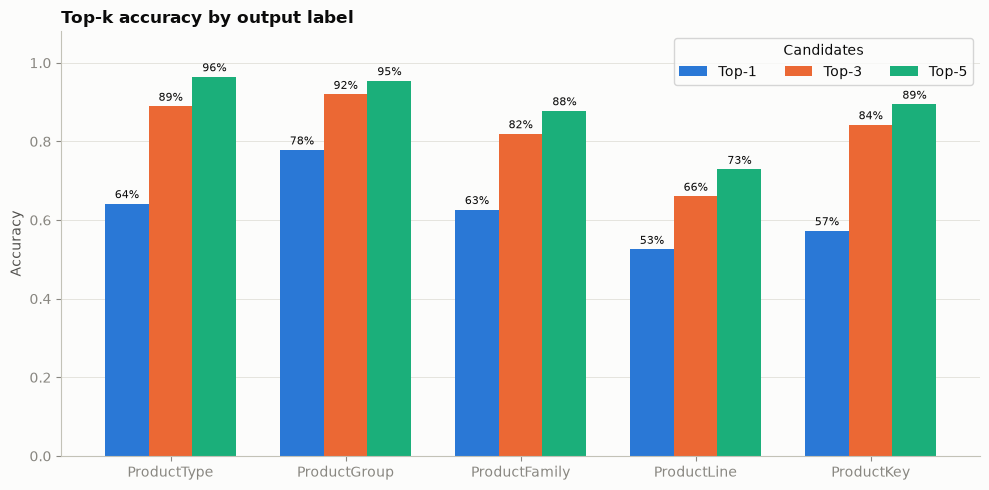

,Top-1,Top-3,Top-5
ProductType,64.2%,88.9%,96.5%
ProductGroup,77.8%,92.0%,95.5%
ProductFamily,62.7%,82.0%,87.8%
ProductLine,52.6%,66.1%,72.9%
ProductKey,57.3%,84.3%,89.5%


In [24]:
def top_k_accuracy(proba, classes, y_true, k):
    class_to_idx = {c: i for i, c in enumerate(classes)}
    true_idx = y_true.map(class_to_idx).to_numpy()
    top_k_idx = np.argsort(proba, axis=1)[:, -k:]
    return np.mean([t in row for t, row in zip(true_idx, top_k_idx)])


topk_accuracy_by_target = {}
for TARGET in TARGETS:
    data = model_data[TARGET]
    topk_accuracy_by_target[TARGET] = {
        "Top-1": top_k_accuracy(data["proba_test"], data["classes"], data["y_test"], 1),
        "Top-3": top_k_accuracy(data["proba_test"], data["classes"], data["y_test"], 3),
        "Top-5": top_k_accuracy(data["proba_test"], data["classes"], data["y_test"], 5),
    }

topk_df = pd.DataFrame(topk_accuracy_by_target).T
ax = topk_df.plot(
    kind="bar",
    figsize=(10, 5),
    color=PALETTE["categorical"][:3],
    width=0.75,
)
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.08)
ax.set_title("Top-k accuracy by output label", loc="left", fontweight="bold")
ax.grid(axis="y", linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(title="Candidates", ncol=3)
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container, labels=[f"{value:.0%}" for value in container.datavalues], padding=2, fontsize=8)
plt.tight_layout()
plt.show()

topk_df.style.format("{:.1%}")

In [25]:
for TARGET in TARGETS:
    print(f"\n{TARGET}")
    display(df[df['UNSPSCNumber'] == '43231512'][TARGET].value_counts(normalize=True))


ProductType


ProductType
License Key & Serial Numbers    0.444444
Software Products               0.176245
Bundle                          0.149425
Main Products                   0.068966
Fees                            0.065134
Configurable Product            0.049808
Service Agreement               0.026820
Content                         0.011494
Service Elearning Course        0.003831
Other                           0.003831
Name: proportion, dtype: float64


ProductGroup


ProductGroup
Resuscitation Programs             0.233716
Simulation Programs                0.203065
Virtual Simulation & e-Learning    0.153257
Other                              0.122605
SimCapture                         0.107280
Simulation and Skills Software     0.057471
Knowledge Res                      0.053640
Adult Patient Simulators           0.038314
BLS                                0.015326
Technical Services                 0.007663
Baby and Pediatric Simulators      0.003831
Laerdal Global Health              0.003831
Name: proportion, dtype: float64


ProductFamily


ProductFamily
HeartCode                             0.164751
Other                                 0.157088
Virtual Products                      0.149425
Emergency Care                        0.141762
SimCapture                            0.114943
LLEAP-Laerdal Learning Application    0.057471
Resuscitation                         0.042146
Electronic Media                      0.034483
Advanced Patient Simulators           0.022989
American Heart Associaton             0.022989
Printed Material                      0.019157
vSim CP+                              0.019157
Custom & Consulting Services          0.011494
Sim Center                            0.007663
Installation                          0.007663
Customised                            0.007663
Resusci Baby                          0.003831
Intermediate Patient Simulators       0.003831
Maternal & Neonatal                   0.003831
Feedback applications                 0.003831
VSim                                  0.003831


ProductLine


ProductLine
Other                                  0.233716
Mobile Simulation                      0.180077
SimCapture Cloud                       0.095785
General                                0.065134
Instructions                           0.053640
LLEAP                                  0.049808
RQI                                    0.038314
HeartCode BLS                          0.038314
SW Licences                            0.034483
Training Products                      0.026820
NRP                                    0.026820
vSim                                   0.019157
Birthing models                        0.015326
Harvey The Cardio Patient Simulator    0.011494
Little Anne QCPR                       0.011494
SimCapture On-Premise                  0.011494
Accelerating to Practice               0.011494
Nursing                                0.011494
Little Junior QCPR                     0.007663
Baby Anne                              0.007663
SimView                     


ProductKey


ProductKey
ITPO     0.252874
CFBL     0.160920
FKDP     0.126437
Other    0.072797
EJDW     0.068966
DIDO     0.061303
BEDS     0.049808
FKDK     0.045977
ISDS     0.030651
DIDK     0.026820
ITPT     0.015326
EJSL     0.015326
AADO     0.011494
AADP     0.007663
AAPO     0.007663
GOPO     0.007663
AAPS     0.003831
GOPC     0.003831
ISDP     0.003831
HPPS     0.003831
ITPS     0.003831
FKBB     0.003831
FKSL     0.003831
EJPO     0.003831
CFSL     0.003831
BEPO     0.003831
Name: proportion, dtype: float64

## Reusable inference function

This extends the function the Streamlit app calls: raw `GPCBrickCode`/`UNSPSCNumber`/`ProductDescription` in, ranked `(label, probability)` list out. `ProductType` remains the default target.

In [26]:
def predict_topk(gpc_brick_code, unspsc_number, product_description, k=3, target="ProductType"):
    data = model_data[target]
    gpc_val = gpc_brick_code if gpc_brick_code else "Missing"
    try:
        unspsc_val = str(int(unspsc_number))
    except (TypeError, ValueError):
        unspsc_val = "-1"

    row_cat = data["ohe"].transform(pd.DataFrame([[gpc_val, unspsc_val]], columns=CAT_FEATURES))

    text = (product_description or "").strip()
    if text:
        row_text = embedder.encode([text], convert_to_numpy=True)
    else:
        row_text = np.zeros((1, embed_dim), dtype=np.float32)

    row_X = np.hstack([row_cat, row_text])
    proba_row = data["model"].predict_proba(row_X)[0]
    return top_k_from_proba(proba_row, data["model"].classes_, k=k)


# Example: a row from the data, called through the same path the Streamlit app will use
example = df.iloc[3]
print("Input:", example["GPCBrickCode"], "|", example["UNSPSCNumber"], "|", example[TEXT_FEATURE][:60], "...")
for TARGET in TARGETS:
    print(TARGET, predict_topk(example["GPCBrickCode"], example["UNSPSCNumber"], example[TEXT_FEATURE], target=TARGET))

Input: 99999999 - Temporary Classification | 42301502 | Bariatric complete suit in light skin tone ...
ProductType [('Main Products', np.float64(0.8691280431302907)), ('Accessories', np.float64(0.034260106190001735)), ('Spare Parts', np.float64(0.03378517478386306))]
ProductGroup [('Adult Patient Simulators', np.float64(0.7751236391290427)), ('Other', np.float64(0.0769816284806568)), ('Skill Trainers', np.float64(0.03818594180780609))]
ProductFamily [('Basic Patient Simulators', np.float64(0.8400084187904018)), ('Advanced Patient Simulators', np.float64(0.02964877144887806)), ('Accessories (Training)', np.float64(0.023378532507530376))]
ProductLine [('Other', np.float64(0.8162941176470588)), ('SimMan 3G', np.float64(0.035)), ('Harvey The Cardio Patient Simulator', np.float64(0.013333333333333334))]
ProductKey [('AAPO', np.float64(0.7401107042037872)), ('ITPO', np.float64(0.1067738007556345)), ('ADPP', np.float64(0.020737947709902286))]


In [27]:
{TARGET: model_data[TARGET]["X_test"].shape for TARGET in TARGETS}

{'ProductType': (1918, 586),
 'ProductGroup': (1918, 587),
 'ProductFamily': (1918, 589),
 'ProductLine': (1918, 587),
 'ProductKey': (1918, 588)}

## Save model artifacts for the Streamlit app

Each target needs its trained `RandomForestClassifier`, fitted `OneHotEncoder`, and embedding metadata. `SentenceTransformer("all-MiniLM-L6-v2")` is re-downloaded/cached at runtime rather than saved.

In [28]:
from pathlib import Path


ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

artifact_prefixes = {
    "ProductType": "product_type",
    "ProductGroup": "product_group",
    "ProductFamily": "product_family",
    "ProductLine": "product_line",
    "ProductKey": "product_key",
}
for TARGET in TARGETS:
    prefix = artifact_prefixes[TARGET]
    data = model_data[TARGET]
    joblib.dump(data["model"], ARTIFACT_DIR / f"{prefix}_rf_3feat_model.joblib")
    joblib.dump(data["ohe"], ARTIFACT_DIR / f"{prefix}_rf_3feat_ohe.joblib")
    joblib.dump(
        {"embed_model_name": EMBED_MODEL_NAME, "embed_dim": embed_dim},
        ARTIFACT_DIR / f"{prefix}_rf_3feat_meta.joblib",
    )
    print(f"Saved {prefix} artifacts to {ARTIFACT_DIR}")

Saved product_type artifacts to artifacts
Saved product_group artifacts to artifacts
Saved product_family artifacts to artifacts
Saved product_line artifacts to artifacts
Saved product_key artifacts to artifacts
